In [1]:
import glob
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
# geopandas extends pandas to handle geospatial data and perform operations on geographic shapes.
import geopandas as gpd
# matplotlib.colors provides tools to define and manipulate colormaps for visualizations.
import matplotlib.colors as mcolors
# ListedColormap allows the creation of custom colormaps for visualizations.
from matplotlib.colors import ListedColormap
from pathlib import Path
from typing import List
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor


from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from scipy.optimize import nnls
#import matplotlib.colormaps as cm
import matplotlib.markers as mmarkers

In [2]:


def collect_files(base_dir: str, dirs: List[str], subpath: str, pattern: str, exclude: str = None) -> List[str]:
    """
    Collects files matching a pattern from specified subdirectories.

    Parameters:
        base_dir (str): Base directory containing all subdirectories.
        dirs (List[str]): List of subdirectory names.
        subpath (str): Relative path inside each subdirectory where files are located.
        pattern (str): Glob pattern to match files.
        exclude (str, optional): String pattern to exclude from results.

    Returns:
        List[str]: Sorted list of matching file paths as strings.
    """
    all_files = []
    for d in dirs:
        search_path = Path(base_dir) / d / subpath / pattern
        files = sorted(search_path.parent.glob(search_path.name))
        if exclude:
            files = [f for f in files if exclude not in f.name]
        all_files.extend([str(f) for f in files])
    return all_files

# Base directory and subdirectories
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"
dirs = [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b740-sep-25", "b741-sep-26", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b747-oct-01", "b748-oct-02", 
    "b749-oct-03", "b750-oct-03"
]

# Collect files
core_processed_files = collect_files(base_dir, dirs, "core_processed", "core_faam*r1*.nc", exclude="_1hz")
dry_neph_files = collect_files(base_dir, dirs, "mo-non-core", "metoffice*neph1*.nc")
flight_sum_files = collect_files(base_dir, dirs, ".", "flight-sum*.txt")
sp2_files = collect_files(base_dir, dirs, "non-core", "man-sp2*.na")
ams_files = collect_files(base_dir, dirs, "non-core", "man-ams*.na")

# Example: print or pass them into other analysis
# print(core_processed_files)


In [3]:
# Function to extract flight number (e.g., "b734") from a file path
def extract_flight_number(file_path):
    match = re.search(r'b\d{3}', file_path)
    return match.group(0) if match else None  # Returns None if no match

# Get flight numbers for each dataset
flights_nc = {extract_flight_number(f) for f in core_processed_files}
flights_ams = {extract_flight_number(f) for f in dry_neph_files}
flights_sp2 = {extract_flight_number(f) for f in sp2_files}
flights_neph = {extract_flight_number(f) for f in ams_files}
flights_sum = {extract_flight_number(f) for f in flight_sum_files}

# Find flights that are in all three datasets
common_flights = flights_nc & flights_ams & flights_sp2 & flights_neph & flights_sum # Set intersection

# Filter the file lists to include only matching flights
filtered_nc = [f for f in core_processed_files if extract_flight_number(f) in common_flights]
filtered_ams = [f for f in ams_files if extract_flight_number(f) in common_flights]
filtered_sp2 = [f for f in sp2_files if extract_flight_number(f) in common_flights]
filtered_neph = [f for f in dry_neph_files if extract_flight_number(f) in common_flights]
filtered_sum = [f for f in flight_sum_files if extract_flight_number(f) in common_flights]

# Print the results
print(f"Common flights: {sorted(common_flights)}")
print(f"Filtered NC files: {len(filtered_nc)}")
print(f"Filtered AMS files: {len(filtered_ams)}")
print(f"Filtered SP2 files: {len(filtered_sp2)}")
print(f"Filtered Neph files: {len(filtered_neph)}")
print(f"Filtered Flight sum files: {len(filtered_sum)}")

Common flights: ['b734', 'b737', 'b739', 'b740', 'b741', 'b742', 'b743', 'b744', 'b745', 'b746', 'b747', 'b748', 'b749', 'b750']
Filtered NC files: 14
Filtered AMS files: 14
Filtered SP2 files: 14
Filtered Neph files: 14
Filtered Flight sum files: 14


In [4]:
def convert_time_to_datetime_sp2(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_ams(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_start_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_neph(dsf, start_date_str):
    
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")

    key_options = ["neph_spm", "NEPH_SPM"]  # Possible variations of the key
    matching_key = next((key for key in key_options if key in dsf), None)
    
    if matching_key:
        time_seconds_t = dsf[matching_key].values
    else:
        raise KeyError("Variable 'neph_spm' not found in dataset.")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    #time_seconds = dsf["neph_spm"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds_t])

    dsf = dsf.assign_coords(time=dsf['neph_spm'])
    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))
    #dsf["Times"] = (("time",), datetime_values)
    #dsf["datetime"] = (("time",), datetime_values)
    #dsf = dsf.set_coords('neph_spm')

    return dsf

In [5]:
def dataset_sp2_ams_neph(file_path_sp2,file_path_ams,file_path_neph):

    with open(file_path_sp2, "rb") as f:
        lines_sp2 = f.readlines()  # Read the first 100 bytes
    with open(file_path_ams, "rb") as f:
        lines_ams = f.readlines()  # Read the first 100 bytes
        
    metadata_lines_sp2 = lines_sp2[:39]  # 39 lines are metadata
    header_line_sp2 = metadata_lines_sp2[38].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_sp2 = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_sp2]
    # Decode if metadata contains byte strings
    metadata_lines_sp2 = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_sp2]
    #print(header_line_sp2)

    metadata_lines_ams = lines_ams[:46]   # 46 lines are metadata
    header_line_ams = metadata_lines_ams[45].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_ams = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_ams]
    # Decode if metadata contains byte strings
    metadata_lines_ams = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_ams]
    #print(header_line_ams)

    data_lines_sp2 = lines_sp2[39:]  # Actual data starts after metadata
    data_lines_ams = lines_ams[46:]
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_sp2], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_sp2 = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_sp2)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_sp2[:38])}  # Store metadata as an attribute
    )
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_ams], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_ams = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_ams)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_ams[:45])}  # Store metadata as an attribute
    )
 
    # Extract the date (format: yyyymmdd)
    match_sp2 = re.search(r'(\d{8})', file_path_sp2)
    # Get the matched date or None if not found
    flight_date_sp2 = match_sp2.group(1) if match_sp2 else None

    # Extract the date (format: yyyymmdd)
    match_ams = re.search(r'(\d{8})', file_path_ams)
    # Get the matched date or None if not found
    flight_date_ams = match_ams.group(1) if match_ams else None


    ds_neph = xr.open_dataset(file_path_neph,decode_times=False)

    # Extract the date (format: yyyymmdd)
    match_neph = re.search(r'(\d{8})', file_path_neph)
    # Get the matched date or None if not found
    flight_date_neph = match_neph.group(1) if match_neph else None
    
    # Convert time
    ds0_sp2 = convert_time_to_datetime_sp2(ds0_sp2, flight_date_sp2)
    ds0_ams = convert_time_to_datetime_ams(ds0_ams, flight_date_ams)
    ds_neph = convert_time_to_datetime_neph(ds_neph, flight_date_neph)
    
    #TM,AD= calculate_total_mass(ds_sp2,ds_ams)

    return ds0_sp2,ds0_ams,ds_neph

In [6]:
def Nc_file_treatment(aux_ds_sp2,aux_ds_ams,aux_ds_psap):
    # List of variables to check for invalid values
    variables = ["SO4", "NH4", "ORG", "NO3","Chl"]
    variables_unc = [f"{var}_uncertainty" for var in variables]
    components = ["BC_mass"]

    #(aux_ds_sp2["BC_mass"] != 9999999) & (aux_ds_sp2["BC_mass"] >= 0)
    # Build a combined valid mask using xarray operations
    valid_mask = (aux_ds_ams[variables[0]] != 9999999) & (aux_ds_ams[variables[0]] >= 0)
    for var in variables[1:]:
        valid_mask = valid_mask & (aux_ds_ams[var] != 9999999)  & (aux_ds_ams[var]  >= 0)
    
    # Apply the combined mask to the whole dataset
    filtered_ds = aux_ds_ams.where(valid_mask, drop=True)

    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass"] = filtered_ds_BC_mass["BC_mass"] * 1e-3

    # Resample to 1-minute means
    resampled_ams = filtered_ds.resample(datetime="1min").mean()
    resampled_psap = aux_ds_psap.resample(Time='1min').mean()
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="1min").mean()

    #print(resampled_ds['time'].shape)
    #print(resampled_ds_sp2['BC_mass'].shape)

    # Calculate total mass across selected components
    total_mass_ams = sum(resampled_ams[var] for var in variables)
    #print(total_mass_ams)
    total_mass_bc = sum(resampled_ds_sp2[var] for var in components)
    #print(total_mass)
    total_mass = total_mass_ams + total_mass_bc
    
    # Extract variables
    bc_mass = resampled_ds_sp2
    so4 = resampled_ams["SO4"]
    nh4 = resampled_ams["NH4"]
    org = resampled_ams["ORG"]
    no3 = resampled_ams["NO3"]
    amonium_sulfate_nitrate = so4+nh4+no3
    #amonium_nitrate = nh4+no3
    #chl = resampled_ams["Chl"]

    
    # Stack the values
    data_masses = [bc_mass, amonium_sulfate_nitrate, org]
    

    # Compute total uncertainty (quadrature sum)
    total_uncertainty_ams = np.sqrt(sum((resampled_ams[unc] ** 2 for unc in variables_unc)))
    total_uncertainty = total_uncertainty_ams  # Assuming BC_mass has no uncertainty provided

    common_times = np.intersect1d(total_mass_bc["time"], total_mass_ams["time"])
    

    valid_PSAP_mask = (
        (resampled_psap["CO_AERO_FLAG"] == 0) &
        (resampled_psap["CO_AERO"] >= 200) &
        (resampled_psap["GPS_ALT"] <= 3000)
    )
    filtered_ds_psap = resampled_psap.where(valid_PSAP_mask, drop=False)
    filtered_ds_psap_aux = resampled_psap.where(valid_PSAP_mask, drop=True)
    
    total_mass_matched = total_mass.sel(time=common_times)
    ds_psap_matched = filtered_ds_psap.sel(data_point=common_times)
    total_mass_matched_uncertanty = total_uncertainty.sel(time=common_times)

    psap_time = filtered_ds_psap_aux['data_point'].values
    mask = xr.DataArray(np.isin(psap_time, common_times), dims=["data_point"])
    ds_psap_matched_aux = filtered_ds_psap_aux.where(mask, drop=True)
    

    
    return ds_psap_matched,total_mass_matched,total_mass_matched_uncertanty,ds_psap_matched_aux,data_masses

In [7]:
def Nc_file_treatment_v2(aux_ds_sp2, aux_ds_ams, aux_ds_psap):
    import numpy as np
    import xarray as xr

    variables = ["SO4", "NH4", "ORG", "NO3", "Chl"]
    variables_unc = [f"{var}_uncertainty" for var in variables]
    components = ["BC_mass"]

    # Prepare individual valid masks and apply them
    resampled_vars = {}
    resampled_uncs = {}

    for var in variables:
        valid_mask = (aux_ds_ams[var] != 9999999) & (aux_ds_ams[var] >= 0)
        filtered = aux_ds_ams[var].where(valid_mask)
        resampled_vars[var] = filtered.resample(datetime="1min").mean()

    for unc in variables_unc:
        resampled_uncs[unc] = aux_ds_ams[unc].resample(datetime="1min").mean()

    # Process BC_mass
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2["BC_mass"].where(valid_BC_mass_mask) * 1e-3  # Convert to µg/m³
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="1min").mean()

    # Sum only valid AMS components at each time
    total_mass_ams = sum(v.fillna(0) for v in resampled_vars.values())

    # Sum only available AMS uncertainties (quadrature)
    total_uncertainty_ams = np.sqrt(sum((resampled_uncs[unc].fillna(0))**2 for unc in variables_unc))

    # Total BC mass (only one component here)
    total_mass_bc = resampled_ds_sp2

    # Combine AMS + BC total mass
    total_mass = total_mass_ams + total_mass_bc

    # PSAP filtering
    resampled_psap = aux_ds_psap.resample(Time='1min').mean()
    valid_PSAP_mask = (
        (resampled_psap["CO_AERO_FLAG"] == 0) &
        (resampled_psap["CO_AERO"] >= 200) &
        (resampled_psap["GPS_ALT"] <= 3000)
    )
    filtered_ds_psap = resampled_psap.where(valid_PSAP_mask, drop=False)
    filtered_ds_psap_aux = resampled_psap.where(valid_PSAP_mask, drop=True)

    # Match times
    common_times = np.intersect1d(total_mass_bc["time"], total_mass_ams["time"])
    total_mass_matched = total_mass.sel(time=common_times)
    total_mass_matched_uncertainty = total_uncertainty_ams.sel(time=common_times)
    #ds_psap_matched = filtered_ds_psap.sel(data_point=common_times)

    # Create auxiliary PSAP dataset with matching times
    psap_time = filtered_ds_psap_aux['data_point'].values
    mask = xr.DataArray(np.isin(psap_time, common_times), dims=["data_point"])
    ds_psap_matched_aux = filtered_ds_psap_aux.where(mask, drop=True)

    # Optional mass breakdowns
    amonium_sulfate_nitrate = (
        resampled_vars["SO4"].fillna(0) +
        resampled_vars["NH4"].fillna(0) +
        resampled_vars["NO3"].fillna(0)
    )
    org = resampled_vars["ORG"].fillna(0)
    bc_mass = resampled_ds_sp2.fillna(0)

    data_masses = [bc_mass, amonium_sulfate_nitrate, org]

    return ds_psap_matched_aux, total_mass_matched, total_mass_matched_uncertainty, ds_psap_matched_aux, data_masses


In [8]:
def calculate_scatering_eff_v2(aux_ds_sp2,aux_ds_ams,aux_ds_neph):

    # List of variables to check for invalid values
    variables = ["SO4", "NH4", "ORG", "NO3","Chl"]
    variables_unc = [f"{var}_uncertainty" for var in variables]
    components = ["BC_mass"]

    #(aux_ds_sp2["BC_mass"] != 9999999) & (aux_ds_sp2["BC_mass"] >= 0)
    # Build a combined valid mask using xarray operations
    valid_mask = (aux_ds_ams[variables[0]] != 9999999) & (aux_ds_ams[variables[0]] >= 0)
    for var in variables[1:]:
        valid_mask = valid_mask & (aux_ds_ams[var] != 9999999)  & (aux_ds_ams[var]  >= 0)
    
    # Apply the combined mask to the whole dataset
    filtered_ds = aux_ds_ams.where(valid_mask, drop=True)

    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass"] = filtered_ds_BC_mass["BC_mass"] * 1e-3

    # Resample to 1-minute means
    resampled_ams = filtered_ds.resample(datetime="1min").mean()
    resampled_neph = aux_ds_neph.resample(datetime='1min').mean()
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="1min").mean()

    #print(resampled_ds['time'].shape)
    #print(resampled_ds_sp2['BC_mass'].shape)

    # Calculate total mass across selected components
    total_mass_ams = sum(resampled_ams[var] for var in variables)
    #print(total_mass_ams)
    total_mass_bc = sum(resampled_ds_sp2[var] for var in components)
    #print(total_mass)
    total_mass = total_mass_ams + total_mass_bc

    # Compute total uncertainty (quadrature sum)
    total_uncertainty_ams = np.sqrt(sum((resampled_ams[unc] ** 2 for unc in variables_unc)))
    total_uncertainty = total_uncertainty_ams  # Assuming BC_mass has no uncertainty provided

    common_times = np.intersect1d(total_mass_bc["time"], total_mass_ams["time"])

    
    total_mass_matched = total_mass.sel(time=common_times)
    ds_neph_matched = resampled_neph.sel(time=common_times)
    total_mass_matched_uncertanty = total_uncertainty.sel(time=common_times)

    
    return ds_neph_matched,total_mass_matched,total_mass_matched_uncertanty

In [9]:
def growth_func_calc(ds_nc):
    
    # Extract the dew point and time
    T_dew_K = ds_nc['TDEW_GE']  # Dew point temperature in Kelvin
    time = ds_nc['data_point']  # Time variable
    # Extract the True air temperature and time
    T_air_K = ds_nc['TAT_DI_R']  # True air temperature in Kelvin with shape (20998, 32)
    
    # Convert 'Time' to a pandas datetime index for resampling
    # Ensure the 'Time' variable is in seconds or a similar time unit that pandas can work with
    time_index = pd.to_datetime(time.values, unit='s')
    
    T_dew_flat = T_dew_K.values.flatten()
    time_flat_dew = time_index.repeat(T_dew_K.shape[1])  # Repeat the time values for each frequency (4Hz)
    
    
    # Create a pandas DataFrame for easier resampling
    df = pd.DataFrame({'Time': time_flat_dew, 'TDEW_GE': T_dew_flat})
    
    # Resample the data by 1 minute and calculate the mean for each interval
    df_resampled = df.resample('1min', on='Time').mean()
    
    # Convert the resampled dew point temperature back to an xarray
    T_dew_resampled = xr.DataArray(df_resampled['TDEW_GE'].values, 
                                   dims=['time'], 
                                   coords={'time': df_resampled.index.values})
    
    # Step 2: Create a pandas DataFrame for resampling
    # Flatten the TAT_DI_R array to make it 1D for DataFrame construction
    T_air_flat = T_air_K.values.flatten()
    time_flat_air = time_index.repeat(T_air_K.shape[1])  # Repeat the time values for each frequency (32Hz)
    
    # Create a DataFrame with the flattened arrays
    df = pd.DataFrame({'Time': time_flat_air, 'TAT_DI_R': T_air_flat})
    
    # Step 3: Resample the data by 1 minute and compute the mean for each time interval
    df_resampled = df.resample('1min', on='Time').mean()
    
    # Step 4: Convert back to xarray
    T_air_resampled = xr.DataArray(df_resampled['TAT_DI_R'].values, 
                                   dims=['time'], 
                                   coords={'time': df_resampled.index.values})

    # Convert from Kelvin to Celsius
    T_dew_resampled_C = T_dew_resampled - 273.15
    
    # Convert from Kelvin to Celsius
    T_air_resampled_C = T_air_resampled - 273.15
    
    # Convert to Celsius
    T_dew_C = T_dew_resampled_C
    T_air_C = T_air_resampled_C
    
    # Calculate relative humidity using the Magnus formula
    RH = 100 * (np.exp((17.625 * T_dew_C) / (243.04 + T_dew_C)) /
                np.exp((17.625 * T_air_C) / (243.04 + T_air_C)))

    alpha = 0.15
    fh = (1-(RH)/100)**(-alpha)


    return fh

In [10]:
ds_neph = xr.open_dataset(filtered_neph[0],decode_times=False)

In [11]:
ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(filtered_sp2[0],filtered_ams[0],filtered_neph[0])
ds_psap = xr.open_dataset(filtered_nc[0])
ds_ams

<xarray.Dataset> Size: 99kB
Dimensions:          (time: 821)
Coordinates:
  * time             (time) int64 7kB 0 1 2 3 4 5 6 ... 815 816 817 818 819 820
    datetime         (time) datetime64[ns] 7kB 2012-09-18T12:41:28 ... 2012-0...
Data variables: (12/13)
    Time_start_UTC   (time) float64 7kB 4.569e+04 4.572e+04 ... 6.262e+04
    Time_end_UTC     (time) float64 7kB 4.572e+04 4.575e+04 ... 6.263e+04
    Time_mid_UTC     (time) float64 7kB 4.57e+04 4.574e+04 ... 6.263e+04
    SO4              (time) float64 7kB 0.5045 0.4973 0.4592 ... 1e+07 1e+07
    NH4              (time) float64 7kB 0.2257 0.3432 0.0238 ... 1e+07 1e+07
    ORG              (time) float64 7kB 0.7897 1.233 0.2763 ... 1e+07 1e+07
    ...               ...
    Chl              (time) float64 7kB 0.06375 0.01435 0.02502 ... 1e+07 1e+07
    SO4_uncertainty  (time) float64 7kB 0.05692 0.0478 0.0484 ... 1e+07 1e+07
    NH4_uncertainty  (time) float64 7kB 0.2079 0.164 0.163 ... 1e+07 1e+07 1e+07
    ORG_uncertainty  (time) float64 7kB 0.3488 0.2755 0.2742 ... 1e+07 1e+07
    NO3_uncertainty  (time) float64 7kB 0.07126 0.05653 0.05552 ... 1e+07 1e+07
    Chl_uncertainty  (time) float64 7kB 0.03404 0.02763 0.02715 ... 1e+07 1e+07
Attributes:
    Metadata:  46 1001\nWill Morgan, James Allan\nSchool of Earth, Atmospheri...

In [12]:

ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(filtered_sp2[0],filtered_ams[0],filtered_neph[0])
ds_psap = xr.open_dataset(filtered_nc[0])

#Calculate absortion efficiency 
ds_psap_matched,tm_psap_match,tm_psap_match_unc,test,data_masses=Nc_file_treatment_v2(ds_sp2,ds_ams,ds_psap)

#Calculate Scattering efficiency 
ds_neph_matched_un,tm_neph_match,tm_neph_match_unc=calculate_scatering_eff_v2(ds_sp2,ds_ams,ds_neph)

#Extract concentration data
#area_time,data_mass_concentration = Area_plot(ds_sp2,ds_ams,ds_psap)

#Filter absortion data
#valid_neph_mask = ~np.isnan(ds_neph_matched["TSC_BLUU"])
#filtered_ds_neph = ds_neph_matched.where(valid_PSAP_mask, drop=TRUE)
GF = growth_func_calc(ds_psap_matched)



#Filter absortion data
#valid_PSAP_mask = ds_psap_matched["PSAP_LIN_FLAG"] == 0
#filtered_ds_psap = ds_psap_matched.where(valid_PSAP_mask, drop=False)
#filtered_ds_psap_aux = ds_psap_matched.where(valid_PSAP_mask, drop=False)
# Ensure both arrays are 1D and aligned
#psap_values = filtered_ds_psap["PSAP_LIN"]
#tm_values_psap_match = tm_psap_match.values

#Filter CO and Hight data
ds_psap_matched_time = test["data_point"].values  # Reference timestamps
ds_neph_matched_time = ds_neph_matched_un["time"].values
common_times = np.intersect1d(ds_psap_matched_time, ds_neph_matched_time)

#ds_psap_matched = test.sel(data_point=common_times)
# Stack the values
#data_masses = [bc_mass, amonium_sulfate, org, amonium_nitrate]
ds_neph_matched = ds_neph_matched_un.sel(time=common_times)
tm_neph_match = tm_neph_match.sel(time=common_times)
BC_mass_match = data_masses[0].sel(time=common_times)
amonium_sulfate_nitrate_mass_match = data_masses[1].sel(time=common_times)
ORG_mass_match = data_masses[2].sel(time=common_times)
#amonium_nitrate_mass_match = data_masses[3].sel(time=common_times)
#CHL_mass_match = data_masses[5].sel(time=common_times)
#mask = ds_psap_matched_un["PSAP_LIN"].notnull()
#ds_neph_matched = ds_neph_matched_un.where(mask, drop=True)
AUX = (tm_neph_match*1e-6)* GF

# Ensure both arrays are 1D and aligned
#neph_values = ds_neph_matched["TSC_BLUU"].values.squeeze()
#datetimes = ds_neph_matched["Times"]#.values.squeeze()
#tm_values_neph_match = tm_neph_match.squeeze()

# Perform element-wise division, ignoring NaNs
result_sct = np.divide(ds_neph_matched["TSC_BLUU"].values.squeeze(), tm_neph_match*1e-6)
result_sct_growth = np.divide(ds_neph_matched["TSC_BLUU"].values.squeeze(), AUX)


# Compute uncertainty in the scattering efficiency (only considering uncertainty in total_mass)
rel_uncertainty_mass_sct = (tm_neph_match_unc * 1e-6) / tm_neph_match
sct_coeff_uncertainty = np.abs(result_sct * rel_uncertainty_mass_sct)
sct_coeff_uncertainty_growth_correction = np.abs(result_sct_growth * rel_uncertainty_mass_sct)

# Drop NaN values from the result if needed
Mass_scattering_eff = result_sct.where(~np.isnan(result_sct), drop=False)
sct_coeff_uncertainty = sct_coeff_uncertainty.where(~np.isnan(sct_coeff_uncertainty), drop=False)

# Drop NaN values from the result if needed
Mass_scattering_eff_growth_correction = result_sct_growth.where(~np.isnan(result_sct_growth), drop=False)
sct_coeff_uncertainty_growth_correction = sct_coeff_uncertainty_growth_correction.where(~np.isnan(sct_coeff_uncertainty_growth_correction), drop=False)

# Compute the mean, handling cases where the list might be empty
mean_mass_scattering_eff_g = np.nanmean(Mass_scattering_eff) 
std_mass_scattering_eff_g = np.nanstd(Mass_scattering_eff) 
mean_std_sct = std_mass_scattering_eff_g/np.sqrt(len(Mass_scattering_eff))
mean_sct_eff_growth_correction = np.nanmean(Mass_scattering_eff_growth_correction) 


# Extract the flight number (b###) from the file path
match = re.search(r'b\d{3}', filtered_nc[0])  # Looks for 'b' followed by 3 digits
flight_number = match.group(0) if match else "Unknown"
# Extract the date in yyyymmdd format
date_match = re.search(r'(\d{8})', filtered_nc[0])
if date_match:
    date_str = date_match.group(1)
    flight_date = datetime.strptime(date_str, "%Y%m%d").strftime("%Y-%m-%d")
else:
    flight_date = "Unknown"


In [13]:
BC_mass_match.values

array([0.71765486, 0.79443917, 0.96123752, 0.94322823, 0.93774477,
       0.9407655 , 0.95233313, 0.93831923, 0.89519597, 0.84111957,
       0.79913052, 0.80151032, 0.78165848, 0.74526652, 0.7297871 ,
       0.75878117, 0.86427013, 0.85391742, 0.8028588 , 0.92288232,
       0.99099077, 0.8867385 , 0.96556083, 0.95362363, 1.0006142 ,
       0.98966805, 0.97315283, 0.94365088, 0.92967062, 1.18723638,
       1.16136602, 1.1529246 , 1.13423442, 1.21455445, 1.249317  ,
       1.24904117, 1.18350833, 1.12918022, 1.18168117, 1.19766098,
       1.26223567, 1.30646217, 1.277052  , 1.16672293, 1.20460183,
       1.27741978, 1.25818775, 1.29180917, 1.26352667, 1.24537117,
       1.29642522, 1.194172  , 1.18092455, 1.17164543, 1.17151343,
       1.22272527, 1.20698803, 0.99951645, 1.00483675, 1.00256845,
       0.94309183, 0.94401345, 0.90696907, 0.96122222, 0.9684096 ,
       0.94017398, 0.96561045, 0.92045637, 0.90334442, 0.91131725,
       0.89542305, 0.88800215, 0.89381202, 0.86678703, 0.87160

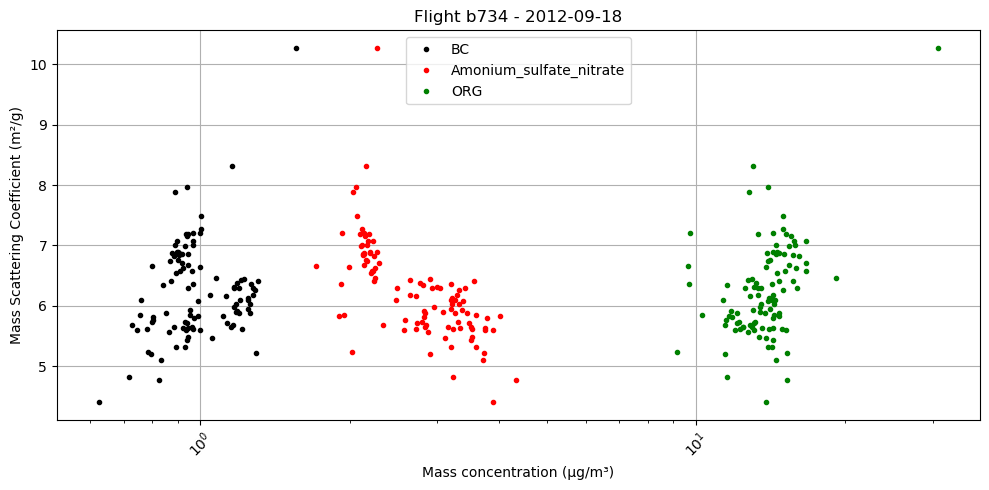

In [14]:
# Create the figure and axis
fig, ax1 = plt.subplots(figsize=(10, 5))

# Define data and corresponding style
species_data = {
    "BC":  (BC_mass_match.values, "black"),
    "Amonium_sulfate_nitrate": (amonium_sulfate_nitrate_mass_match.values, "red"),
    "ORG": (ORG_mass_match.values, "green"),
}

# Plot all species in a loop
for label, (xdata, color) in species_data.items():
    ax1.plot(xdata, Mass_scattering_eff_growth_correction.values,
             marker='.', linewidth=0, color=color, label=label)


ax1.set_xscale('log')
# Set labels and formatting
ax1.set_xlabel("Mass concentration (µg/m³)")
ax1.set_ylabel(r'Mass Scattering Coefficient (m²/g)')
ax1.set_title(f"Flight {flight_number} - {flight_date}")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True)
ax1.legend(loc="best")

plt.tight_layout()
plt.show()

Intercept: 5.600370849941402
Coefficients:
  BC: 1.2026
  Amonium_sulfate_nitrate: -0.9200
  ORG: 0.1441

R²: 0.753
RMSE: 0.395


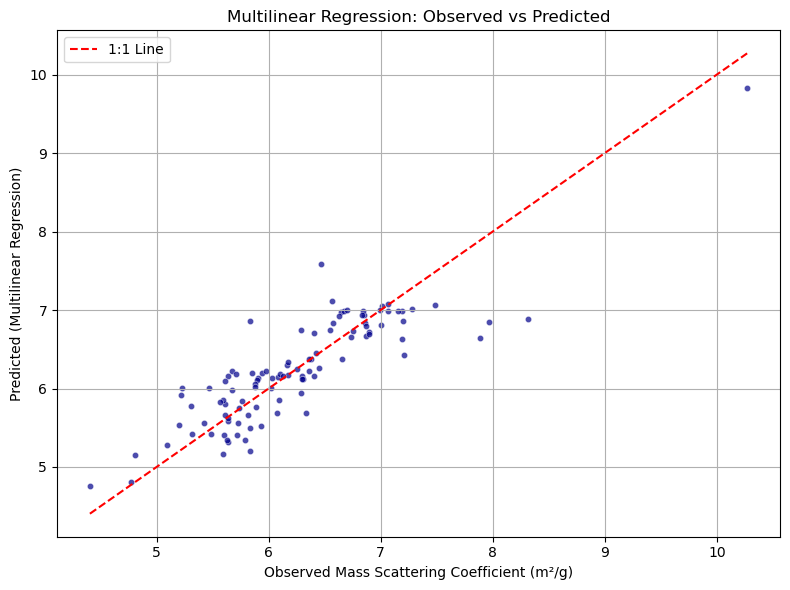

In [15]:
# 1. Prepare input data


X = pd.DataFrame({
    'BC': BC_mass_match.values,
    'Amonium_sulfate_nitrate': amonium_sulfate_nitrate_mass_match.values,
    'ORG': ORG_mass_match.values,
})
y = Mass_scattering_eff_growth_correction.values

# Optional: remove rows with NaNs
valid = X.notnull().all(axis=1) & ~np.isnan(y)
X = X[valid]
y = y[valid]

# 2. Fit linear regression model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

coeffs = pd.Series(model.coef_, index=X.columns)
intercept = model.intercept_

# 3. Print regression coefficients
print("Intercept:", intercept)
print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")

# 4. Evaluate model
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f"\nR²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

# 5. Plot actual vs predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=y_pred, s=20, color='darkblue', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='1:1 Line')
plt.xlabel("Observed Mass Scattering Coefficient (m²/g)")
plt.ylabel("Predicted (Multilinear Regression)")
plt.title("Multilinear Regression: Observed vs Predicted")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("MLR_ObservedvsPredicted_scattering.png")
plt.show()



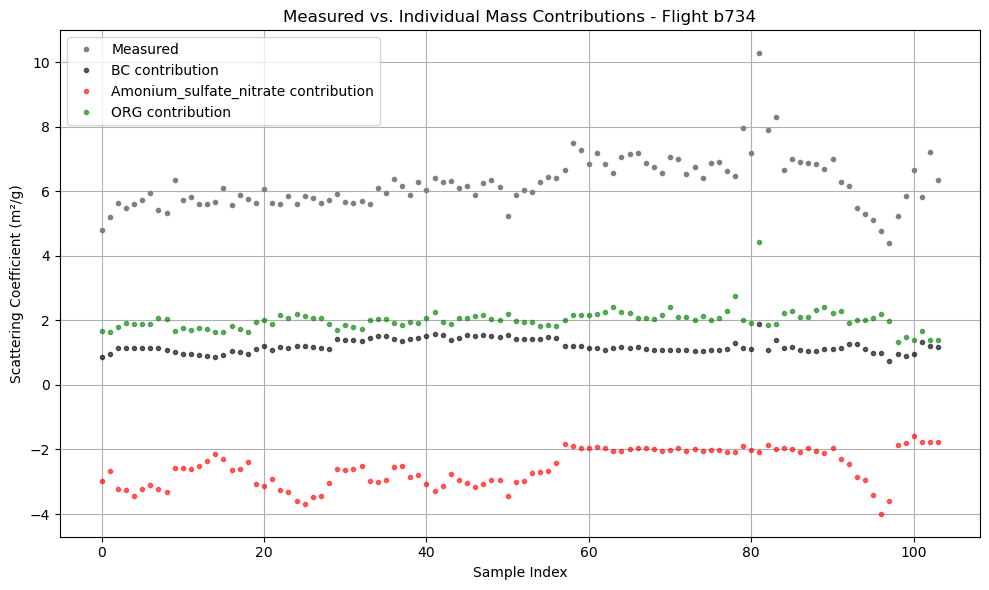

In [16]:
# 6. Plot individual contributions
colors = {
    'BC': 'black',
    'Amonium_sulfate_nitrate': 'red',
    'ORG': 'green',
}

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(y, '.', label='Measured', color='gray')

for name in X.columns:
    contribution = X[name] * model.coef_[X.columns.get_loc(name)]
    ax.plot(contribution, '.', label=f"{name} contribution", color=colors[name], alpha=0.6)

ax.set_xlabel("Sample Index")
ax.set_ylabel("Scattering Coefficient (m²/g)")
ax.set_title(f"Measured vs. Individual Mass Contributions - Flight {flight_number}")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


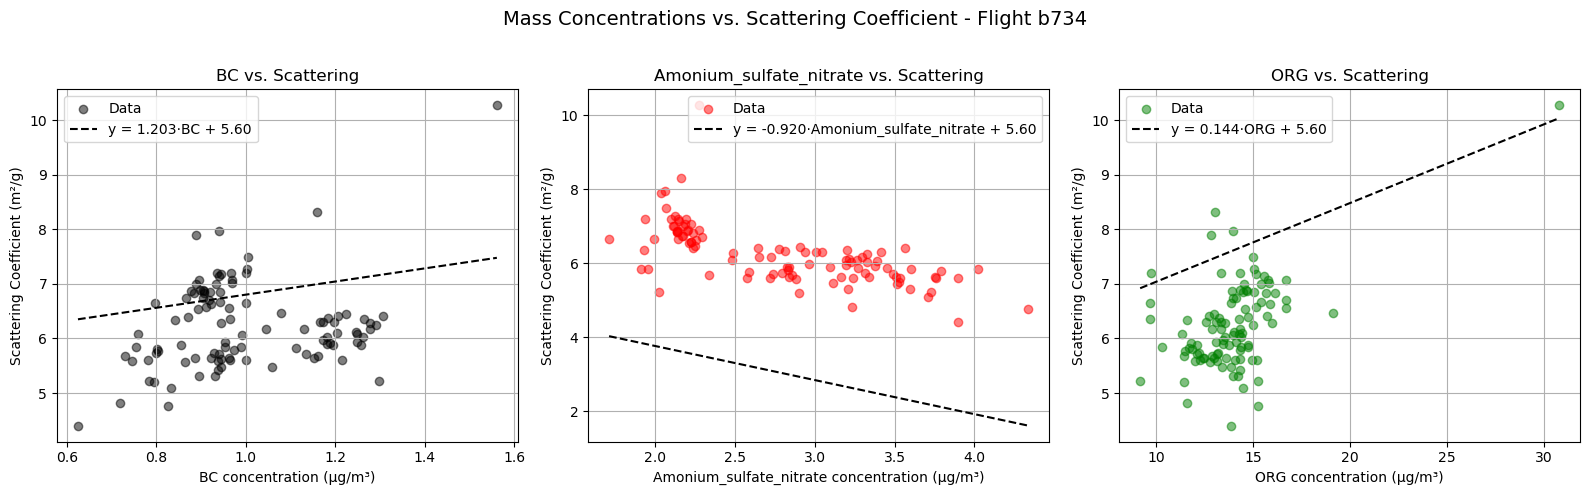

In [17]:
# 4. Scatter plots + linear lines for each variable
colors = {
    'BC': 'black',
    'Amonium_sulfate_nitrate': 'red',
    'ORG': 'green',
}

fig, axs = plt.subplots(1, 3, figsize=(16, 5))
axs = axs.flatten()

for i, name in enumerate(X.columns):
    ax = axs[i]
    xi = X[name]
    ci = coeffs[name]

    # Calculate predicted contribution (ci * xi + intercept is not valid here directly)
    # But we just show the line from multilinear coefficient: y = ci * xi + const
    x_range = np.linspace(xi.min(), xi.max(), 100)
    y_line = ci * x_range + intercept  # Intercept here is the total intercept

    ax.scatter(xi, y, alpha=0.5, color=colors[name], label='Data')
    ax.plot(x_range, y_line, color='k', linestyle='--',
            label=f'y = {ci:.3f}·{name} + {intercept:.2f}')

    ax.set_xlabel(f'{name} concentration (µg/m³)')
    ax.set_ylabel('Scattering Coefficient (m²/g)')
    ax.set_title(f'{name} vs. Scattering')
    ax.grid(True)
    ax.legend()

plt.suptitle(f'Mass Concentrations vs. Scattering Coefficient - Flight {flight_number}', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [18]:
# List to store results
results_sct = []
results_sct_growth = []

# Iterate over all matching flights
for sp2_file, ams_file, nc_file, neph_file in zip(filtered_sp2, filtered_ams, filtered_nc, filtered_neph):
    
    ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(sp2_file,ams_file,neph_file)
    ds_psap = xr.open_dataset(nc_file)
    
    #Calculate absortion efficiency 
    ds_psap_matched,tm_psap_match,tm_psap_match_unc,test,data_masses=Nc_file_treatment_v2(ds_sp2,ds_ams,ds_psap)
    
    #Calculate Scattering efficiency 
    ds_neph_matched_un,tm_neph_match,tm_neph_match_unc=calculate_scatering_eff_v2(ds_sp2,ds_ams,ds_neph)
    
    #Extract concentration data
    #area_time,data_mass_concentration = Area_plot(ds_sp2,ds_ams,ds_psap)
    
    #Filter absortion data
    #valid_neph_mask = ~np.isnan(ds_neph_matched["TSC_BLUU"])
    #filtered_ds_neph = ds_neph_matched.where(valid_PSAP_mask, drop=TRUE)
    GF = growth_func_calc(ds_psap_matched)
    
    
    
    #Filter absortion data
    #valid_PSAP_mask = ds_psap_matched["PSAP_LIN_FLAG"] == 0
    #filtered_ds_psap = ds_psap_matched.where(valid_PSAP_mask, drop=False)
    #filtered_ds_psap_aux = ds_psap_matched.where(valid_PSAP_mask, drop=False)
    # Ensure both arrays are 1D and aligned
    #psap_values = filtered_ds_psap["PSAP_LIN"]
    #tm_values_psap_match = tm_psap_match.values
    
    #Filter CO and Hight data
    ds_psap_matched_time = test["data_point"].values  # Reference timestamps
    ds_neph_matched_time = ds_neph_matched_un["time"].values
    common_times = np.intersect1d(ds_psap_matched_time, ds_neph_matched_time)
    
    #ds_psap_matched = test.sel(data_point=common_times)
    ds_neph_matched = ds_neph_matched_un.sel(time=common_times)
    tm_neph_match = tm_neph_match.sel(time=common_times)
    ds_neph_matched = ds_neph_matched_un.sel(time=common_times)
    tm_neph_match = tm_neph_match.sel(time=common_times)
    BC_mass_match = data_masses[0].sel(time=common_times)
    amonium_sulfate_nitrate_mass_match = data_masses[1].sel(time=common_times)
    ORG_mass_match = data_masses[2].sel(time=common_times)
    #amonium_nitrate_mass_match = data_masses[3].sel(time=common_times)
    #CHL_mass_match = data_masses[5].sel(time=common_times)
    #mask = ds_psap_matched_un["PSAP_LIN"].notnull()
    #ds_neph_matched = ds_neph_matched_un.where(mask, drop=True)
    AUX = (tm_neph_match*1e-6)* GF
    
    # Ensure both arrays are 1D and aligned
    #neph_values = ds_neph_matched["TSC_BLUU"].values.squeeze()
    #datetimes = ds_neph_matched["Times"]#.values.squeeze()
    #tm_values_neph_match = tm_neph_match.squeeze()
    
    # Perform element-wise division, ignoring NaNs
    #result_sct = np.divide(ds_neph_matched["TSC_BLUU"].values.squeeze(), tm_neph_match*1e-6)
    result_sct_growth = np.divide(ds_neph_matched["TSC_BLUU"].values.squeeze(), AUX)
    
    
    # Compute uncertainty in the scattering efficiency (only considering uncertainty in total_mass)
    #rel_uncertainty_mass_sct = (tm_neph_match_unc * 1e-6) / tm_neph_match
    #sct_coeff_uncertainty = np.abs(result_sct * rel_uncertainty_mass_sct)
    #sct_coeff_uncertainty_growth_correction = np.abs(result_sct_growth * rel_uncertainty_mass_sct)
    
    # Drop NaN values from the result if needed
    #Mass_scattering_eff = result_sct.where(~np.isnan(result_sct), drop=False)
    #sct_coeff_uncertainty = sct_coeff_uncertainty.where(~np.isnan(sct_coeff_uncertainty), drop=False)
    
    # Drop NaN values from the result if needed
    Mass_scattering_eff_growth_correction = result_sct_growth.where(~np.isnan(result_sct_growth), drop=False)
    #sct_coeff_uncertainty_growth_correction = sct_coeff_uncertainty_growth_correction.where(~np.isnan(sct_coeff_uncertainty_growth_correction), drop=False)
    
    # Compute the mean, handling cases where the list might be empty
    #mean_mass_scattering_eff_g = np.nanmean(Mass_scattering_eff) 
    #std_mass_scattering_eff_g = np.nanstd(Mass_scattering_eff) 
    #mean_std_sct = std_mass_scattering_eff_g/np.sqrt(len(Mass_scattering_eff))
    mean_sct_eff_growth_correction = np.nanmean(Mass_scattering_eff_growth_correction) 
    
    
    # Extract the flight number (b###) from the file path
    match = re.search(r'b\d{3}', nc_file)  # Looks for 'b' followed by 3 digits
    flight_number = match.group(0) if match else "Unknown"

    

    # Store results in a list
    results_sct.append({
        'BC': BC_mass_match.values,
        'INO': amonium_sulfate_nitrate_mass_match.values,
        'ORG': ORG_mass_match.values,
        'Mass scattering eff (growth correction)': Mass_scattering_eff_growth_correction.values,
        "flight": flight_number
    })


In [19]:
# Create an empty list to store the summary
regression_results = []

# Loop through each flight dict
for entry in results_sct:
    flight = entry['flight']
    
    # Build X and y from the dictionary
    try:
        X = pd.DataFrame({key: entry[key] for key in ['BC', 'INO', 'ORG']})
        y = pd.Series(entry['Mass scattering eff (growth correction)'])
    
        # Remove NaNs (optional safety check)
        valid = X.notnull().all(axis=1) & ~np.isnan(y)
        X = X[valid]
        y = y[valid]
    
        # Add constant (intercept) term
        X_const = sm.add_constant(X)
    
        # Fit model
        model = sm.OLS(y, X_const).fit()
    
        # Add results to the list (one row per parameter)
        for param, coef, std, pval in zip(model.params.index, model.params.values, model.bse.values, model.pvalues.values):
            regression_results.append({
                'Flight': flight,
                'N': len(y),
                'Parameter': param,
                'Coefficient': coef,
                'Std Err': std,
                'p-value': pval,
                'R-squared': model.rsquared if param == 'const' else np.nan,
                'Adj R-squared': model.rsquared_adj if param == 'const' else np.nan,
                'F-statistic': model.fvalue if param == 'const' else np.nan,
                'F p-value': model.f_pvalue if param == 'const' else np.nan
            })


    except Exception as e:
        print(f"Error in flight {flight}: {e}")

# Convert to DataFrame for display
results_df = pd.DataFrame(regression_results)

# Fill R-squared only in one row per flight
results_df['R-squared'] = results_df.groupby('Flight')['R-squared'].transform(lambda x: x.ffill().bfill())

# Display nicely
print(results_df.to_string(index=False))

Flight   N Parameter  Coefficient  Std Err      p-value  R-squared  Adj R-squared  F-statistic    F p-value
  b734 104     const     5.600371 0.323073 6.794240e-32   0.753161       0.745756   101.707644 2.921912e-30
  b734 104        BC     1.202575 0.262088 1.298495e-05   0.753161            NaN          NaN          NaN
  b734 104       INO    -0.920028 0.066298 4.759283e-25   0.753161            NaN          NaN          NaN
  b734 104       ORG     0.144105 0.018335 4.548183e-12   0.753161            NaN          NaN          NaN
  b737  64     const     5.412486 0.464814 4.915161e-17   0.170207       0.128717     4.102398 1.027602e-02
  b737  64        BC     0.778306 0.521518 1.408383e-01   0.170207            NaN          NaN          NaN
  b737  64       INO    -0.019851 0.074310 7.902805e-01   0.170207            NaN          NaN          NaN
  b737  64       ORG    -0.011422 0.005488 4.167783e-02   0.170207            NaN          NaN          NaN
  b739 158     const     6.6

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1718: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1796: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1796: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1718: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1796: RuntimeWarning: divide by zero encounte

In [20]:
# Create an empty list to store the summary
regression_results = []

# Loop through each flight dict
for entry in results_sct:
    flight = entry['flight']
    
    try:
        # Build X and y
        X = pd.DataFrame({key: entry[key] for key in ['BC', 'INO', 'ORG']})
        y = pd.Series(entry['Mass scattering eff (growth correction)'])
    
        # Remove NaNs
        valid = X.notnull().all(axis=1) & ~np.isnan(y)
        X = X[valid]
        y = y[valid]
    
        # Show correlation matrix for diagnostics
        corr_matrix = X.corr()
        print(f"\nCorrelation matrix for flight {flight}:\n{corr_matrix.round(3)}")
    
        # Compute VIFs
        X_vif = sm.add_constant(X)  # VIF expects constant included
        vif = pd.Series(
            [variance_inflation_factor(X_vif.values, i) for i in range(1, X_vif.shape[1])],
            index=X.columns
        )
    
        # Fit model
        X_const = sm.add_constant(X)
        model = sm.OLS(y, X_const).fit()
    
        # Store results
        for param, coef, std, pval in zip(model.params.index, model.params.values, model.bse.values, model.pvalues.values):
            regression_results.append({
                'Flight': flight,
                'N': len(y),
                'Parameter': param,
                'Coefficient': coef,
                'Std Err': std,
                'p-value': pval,
                'R-squared': model.rsquared if param == 'const' else np.nan,
                'Adj R-squared': model.rsquared_adj if param == 'const' else np.nan,
                'F-statistic': model.fvalue if param == 'const' else np.nan,
                'F p-value': model.f_pvalue if param == 'const' else np.nan,
                'VIF': np.nan if param == 'const' else vif.get(param, np.nan)
            })

    except Exception as e:
        print(f"Error in flight {flight}: {e}")

# Convert to DataFrame
results_df = pd.DataFrame(regression_results)

# Fill R-squared and F-stats per flight
results_df['R-squared'] = results_df.groupby('Flight')['R-squared'].transform(lambda x: x.ffill().bfill())
results_df['Adj R-squared'] = results_df.groupby('Flight')['Adj R-squared'].transform(lambda x: x.ffill().bfill())
results_df['F-statistic'] = results_df.groupby('Flight')['F-statistic'].transform(lambda x: x.ffill().bfill())
results_df['F p-value'] = results_df.groupby('Flight')['F p-value'].transform(lambda x: x.ffill().bfill())

# Display
pd.set_option('display.float_format', '{:.3f}'.format)
print(results_df.to_string(index=False))


Correlation matrix for flight b734:
        BC    INO    ORG
BC   1.000  0.229  0.365
INO  0.229  1.000 -0.014
ORG  0.365 -0.014  1.000

Correlation matrix for flight b737:
        BC    INO    ORG
BC   1.000 -0.201 -0.046
INO -0.201  1.000  0.663
ORG -0.046  0.663  1.000

Correlation matrix for flight b739:
        BC    INO    ORG
BC   1.000  0.428  0.414
INO  0.428  1.000  0.928
ORG  0.414  0.928  1.000

Correlation matrix for flight b740:
        BC    INO    ORG
BC   1.000  0.607  0.682
INO  0.607  1.000  0.894
ORG  0.682  0.894  1.000

Correlation matrix for flight b741:
        BC    INO    ORG
BC   1.000 -0.391  0.997
INO -0.391  1.000 -0.322
ORG  0.997 -0.322  1.000

Correlation matrix for flight b742:
        BC    INO    ORG
BC   1.000  0.517  0.794
INO  0.517  1.000  0.554
ORG  0.794  0.554  1.000

Correlation matrix for flight b743:
        BC    INO    ORG
BC   1.000  0.943  0.915
INO  0.943  1.000  0.993
ORG  0.915  0.993  1.000

Correlation matrix for flight b744:
    

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1718: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1796: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1796: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1718: RuntimeWarning: divide by zero encountered in scalar di

In [21]:
# Create an empty list to store the summary
regression_results = []

# Loop through each flight dict
for entry in results_sct:
    flight = entry['flight']
    
    try:
        # Build X and y
        X = pd.DataFrame({key: entry[key] for key in ['BC', 'INO', 'ORG']})
        y = pd.Series(entry['Mass scattering eff (growth correction)'])

        # Remove NaNs
        valid = X.notnull().all(axis=1) & ~np.isnan(y)
        X = X[valid]
        y = y[valid]

        # Show correlation matrix
        print(f"\nCorrelation matrix for flight {flight}:\n{X.corr().round(3)}")

        # VIF
        X_vif = sm.add_constant(X)
        vif = pd.Series(
            [variance_inflation_factor(X_vif.values, i) for i in range(1, X_vif.shape[1])],
            index=X.columns
        )

        ### === Option A: Non-negative least squares === ###
        beta_nnls, _ = nnls(X.values, y.values)

        for param, coef in zip(X.columns, beta_nnls):
            regression_results.append({
                'Flight': flight,
                'N': len(y),
                'Parameter': param,
                'Coefficient': coef,
                'Method': 'NNLS',
                'R-squared': np.nan,
                'Adj R-squared': np.nan,
                'F-statistic': np.nan,
                'F p-value': np.nan,
                'VIF': vif.get(param, np.nan)
            })

        ### === Option B: Ridge Regression (L2) === ###
        ridge = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
        ridge.fit(X, y)
        y_pred_ridge = ridge.predict(X)
        r2_ridge = ridge.score(X, y)

        for param, coef in zip(X.columns, ridge.coef_):
            regression_results.append({
                'Flight': flight,
                'N': len(y),
                'Parameter': param,
                'Coefficient': coef,
                'Method': 'Ridge',
                'R-squared': r2_ridge,
                'Adj R-squared': np.nan,
                'F-statistic': np.nan,
                'F p-value': np.nan,
                'VIF': vif.get(param, np.nan)
            })

        ### === Option C: Lasso Regression (L1) === ###
        lasso = LassoCV(alphas=np.logspace(-3, 3, 100), cv=5, max_iter=10000)
        lasso.fit(X, y)
        y_pred_lasso = lasso.predict(X)
        r2_lasso = lasso.score(X, y)

        for param, coef in zip(X.columns, lasso.coef_):
            regression_results.append({
                'Flight': flight,
                'N': len(y),
                'Parameter': param,
                'Coefficient': coef,
                'Method': 'Lasso',
                'R-squared': r2_lasso,
                'Adj R-squared': np.nan,
                'F-statistic': np.nan,
                'F p-value': np.nan,
                'VIF': vif.get(param, np.nan)
            })

    except Exception as e:
        print(f"Error in flight {flight}: {e}")

# Final table
results_df = pd.DataFrame(regression_results)
pd.set_option('display.float_format', '{:.3f}'.format)
print(results_df.to_string(index=False))



Correlation matrix for flight b734:
       BC    INO    ORG
BC  1.000  0.229  0.365
INO 0.229  1.000 -0.014
ORG 0.365 -0.014  1.000

Correlation matrix for flight b737:
        BC    INO    ORG
BC   1.000 -0.201 -0.046
INO -0.201  1.000  0.663
ORG -0.046  0.663  1.000

Correlation matrix for flight b739:
       BC   INO   ORG
BC  1.000 0.428 0.414
INO 0.428 1.000 0.928
ORG 0.414 0.928 1.000

Correlation matrix for flight b740:
       BC   INO   ORG
BC  1.000 0.607 0.682
INO 0.607 1.000 0.894
ORG 0.682 0.894 1.000

Correlation matrix for flight b741:
        BC    INO    ORG
BC   1.000 -0.391  0.997
INO -0.391  1.000 -0.322
ORG  0.997 -0.322  1.000
Error in flight b741: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=3.

Correlation matrix for flight b742:
       BC   INO   ORG
BC  1.000 0.517 0.794
INO 0.517 1.000 0.554
ORG 0.794 0.554 1.000


/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



Correlation matrix for flight b743:
       BC   INO   ORG
BC  1.000 0.943 0.915
INO 0.943 1.000 0.993
ORG 0.915 0.993 1.000


/srv/conda/envs/notebook/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/srv/conda/envs/notebook/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/srv/conda/envs/notebook/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/srv/conda/envs/notebook/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/srv/conda/envs/notebook/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is 


Correlation matrix for flight b744:
       BC   INO   ORG
BC  1.000 0.405 0.521
INO 0.405 1.000 0.818
ORG 0.521 0.818 1.000

Correlation matrix for flight b745:
       BC   INO   ORG
BC  1.000 0.658 0.654
INO 0.658 1.000 0.880
ORG 0.654 0.880 1.000

Correlation matrix for flight b746:
       BC   INO   ORG
BC  1.000 0.761 0.812
INO 0.761 1.000 0.862
ORG 0.812 0.862 1.000

Correlation matrix for flight b747:
       BC   INO   ORG
BC  1.000 0.958 0.917
INO 0.958 1.000 0.977
ORG 0.917 0.977 1.000
Error in flight b747: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=4.

Correlation matrix for flight b748:
       BC   INO   ORG
BC  1.000 0.560 0.733
INO 0.560 1.000 0.682
ORG 0.733 0.682 1.000

Correlation matrix for flight b749:
       BC   INO   ORG
BC  1.000 1.000 1.000
INO 1.000 1.000 1.000
ORG 1.000 1.000 1.000
Error in flight b749: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=2.

Correlation matrix for flig

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1783: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [22]:
# Store NNLS regression results
nnls_results = []

# Loop through each flight entry
for entry in results_sct:
    flight = entry['flight']

    try:
        # Prepare X (predictors) and y (target)
        X = pd.DataFrame({
            'BC': entry['BC'],
            'INO': entry['INO'],
            'ORG': entry['ORG'],
        })
        y = pd.Series(entry['Mass scattering eff (growth correction)'])

        # Drop NaNs
        valid = X.notnull().all(axis=1) & ~np.isnan(y)
        X = X[valid]
        y = y[valid]

        # Apply NNLS
        coef, residual_norm = nnls(X.values, y.values)

        # Compute predictions and R²
        y_pred = X @ coef
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r_squared = 1 - ss_res / ss_tot

        # Store results
        for i, param in enumerate(X.columns):
            nnls_results.append({
                'Flight': flight,
                'Parameter': param,
                'Coefficient': coef[i],
                'R-squared': r_squared if i == 0 else np.nan,
                'Residual norm': residual_norm if i == 0 else np.nan,
                'N': len(y)
            })

    except Exception as e:
        print(f"Error in flight {flight}: {e}")

# Convert to DataFrame and display
nnls_df = pd.DataFrame(nnls_results)
nnls_df['R-squared'] = nnls_df.groupby('Flight')['R-squared'].transform(lambda x: x.ffill().bfill())
print(nnls_df.to_string(index=False))

Flight Parameter  Coefficient  R-squared  Residual norm   N
  b734        BC        2.044     -0.102          8.517 104
  b734       INO        0.000     -0.102            NaN 104
  b734       ORG        0.298     -0.102            NaN 104
  b737        BC        5.494     -1.825         22.321  64
  b737       INO        0.266     -1.825            NaN  64
  b737       ORG        0.000     -1.825            NaN  64
  b739        BC       16.027     -0.661         36.804 158
  b739       INO        0.000     -0.661            NaN 158
  b739       ORG        0.000     -0.661            NaN 158
  b740        BC        2.403     -4.776          7.118  22
  b740       INO        0.000     -4.776            NaN  22
  b740       ORG        0.247     -4.776            NaN  22
  b741        BC        0.000     -0.391          1.264   3
  b741       INO        1.391     -0.391            NaN   3
  b741       ORG        1.923     -0.391            NaN   3
  b742        BC        1.604     -3.003

/tmp/ipykernel_504/249130353.py:29: RuntimeWarning: invalid value encountered in scalar divide
  r_squared = 1 - ss_res / ss_tot


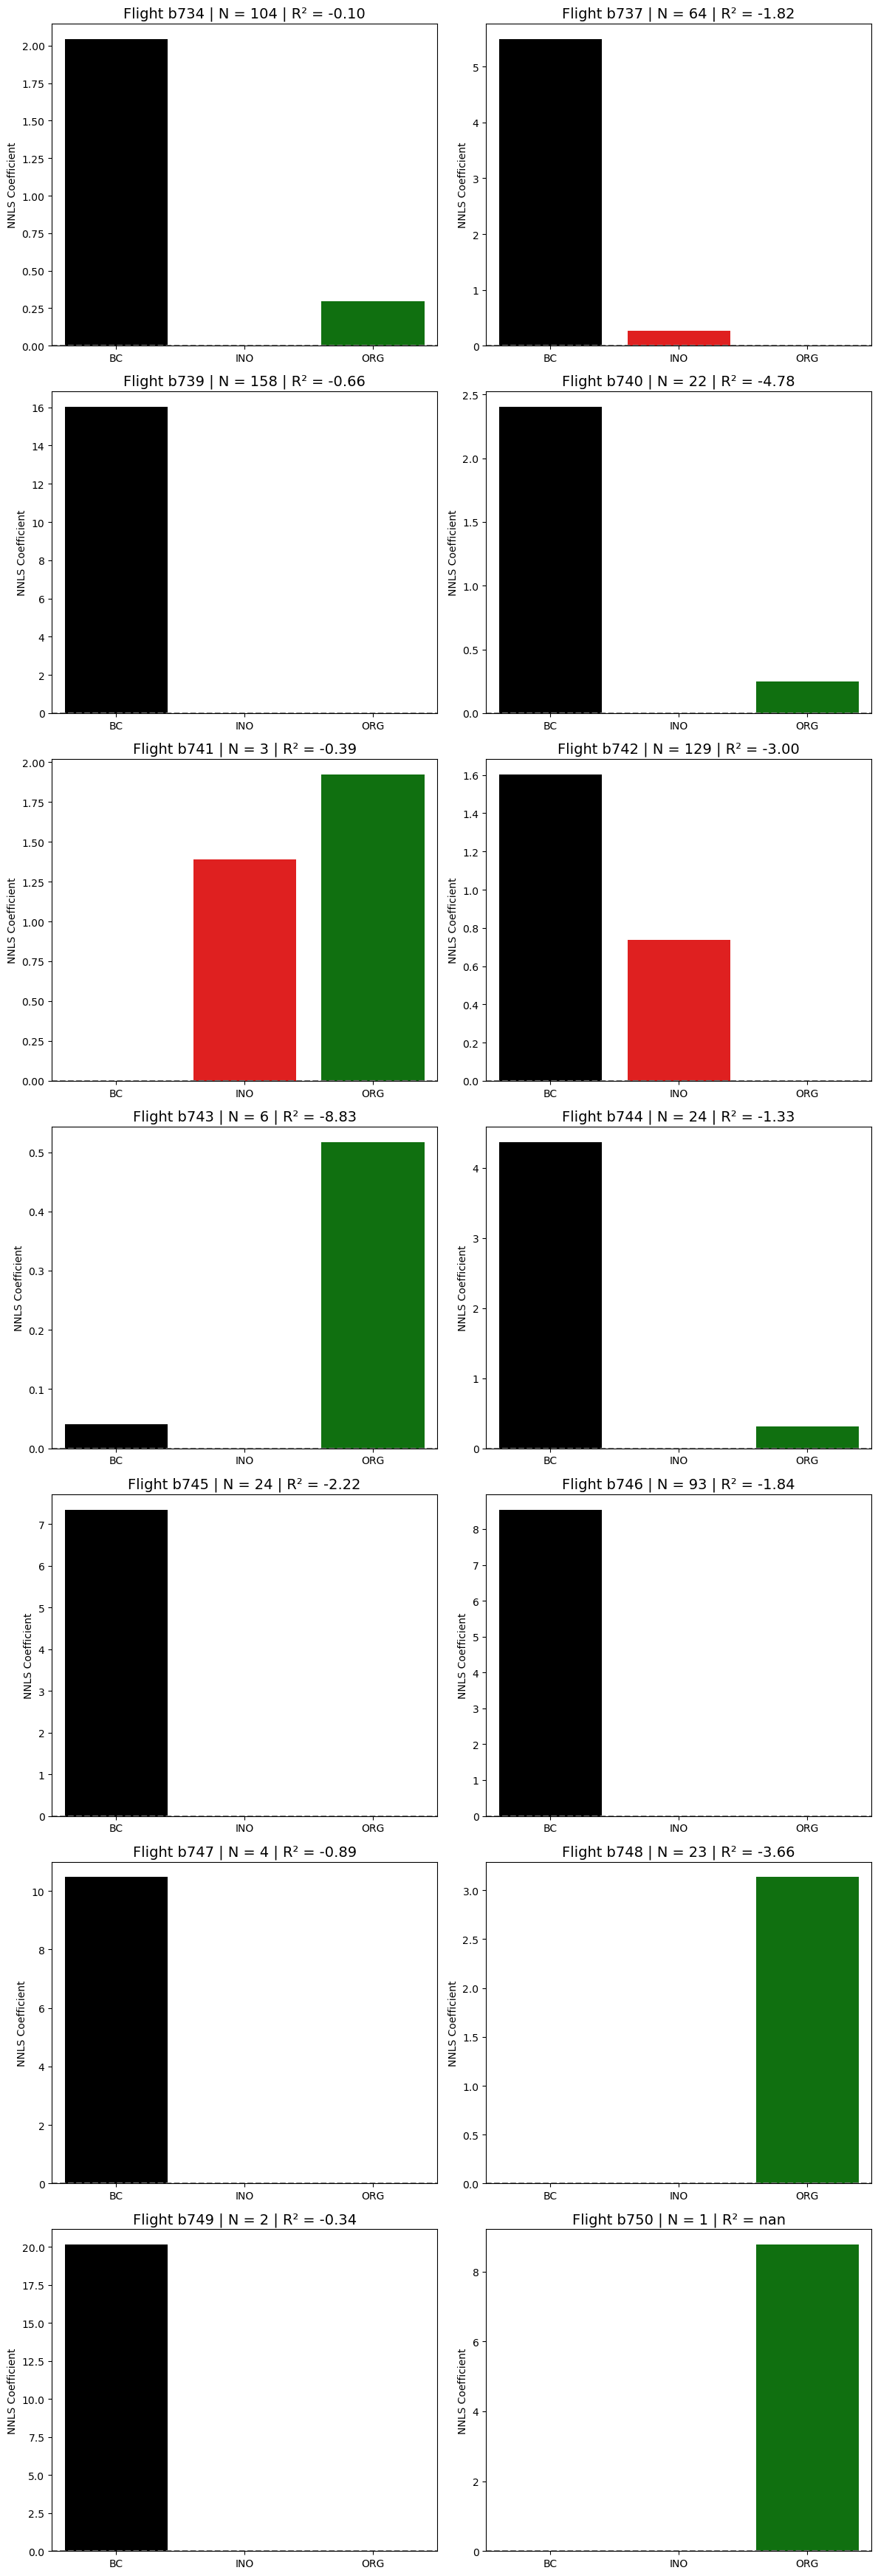

In [23]:



# Assuming `nnls_df` contains: Flight, Parameter, Coefficient, R-squared, N

# Copy and prep
df_coef = nnls_df.copy()
flights = df_coef['Flight'].unique()

# Subplot config
ncols = 2
nrows = (len(flights) + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows), squeeze=False)

# Custom colors
colors = {
    'BC': 'black',
    'INO': 'red',
    'ORG': 'green',
}

for idx, flight in enumerate(flights):
    ax = axes[idx // ncols, idx % ncols]

    # Filter data for this flight
    flight_df = df_coef[df_coef['Flight'] == flight]
    N = flight_df['N'].unique()[0]
    R2 = flight_df['R-squared'].iloc[0]

    # Plot bars
    sns.barplot(
        data=flight_df,
        x='Parameter', y='Coefficient',
        hue='Parameter', palette=colors,
        errorbar=None, ax=ax, legend=False
    )

    ax.axhline(0, color='gray', linestyle='--')
    ax.set_title(f"Flight {flight} | N = {N} | R² = {R2:.2f}", fontsize=14)
    ax.set_ylabel("NNLS Coefficient")
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig("NNLS_coefficients_scattering.png")

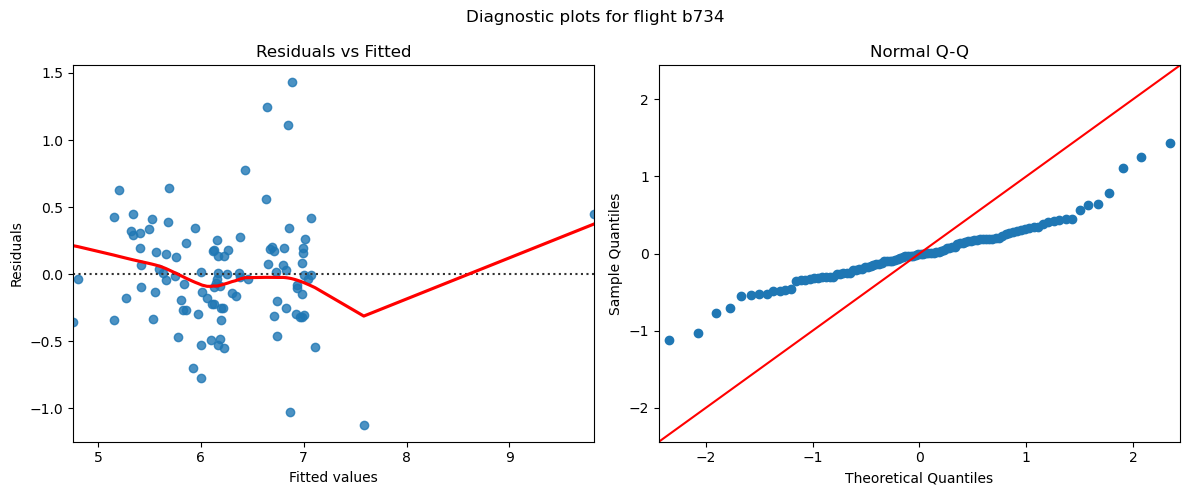

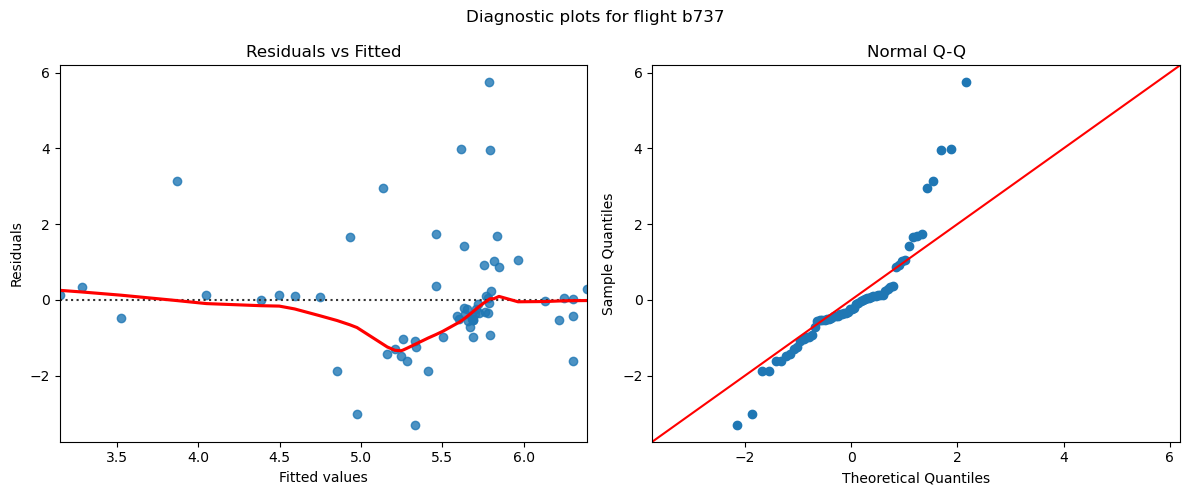

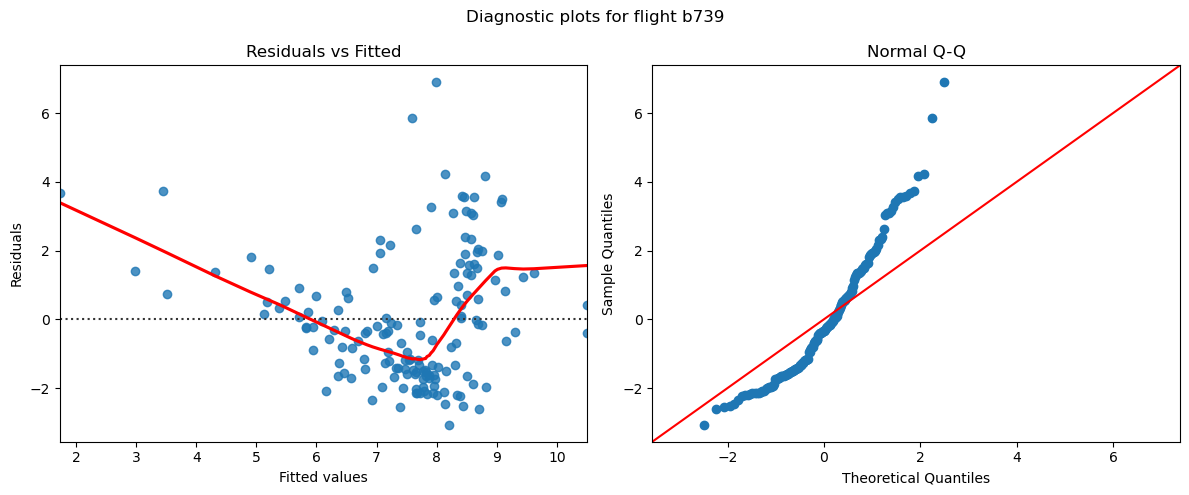

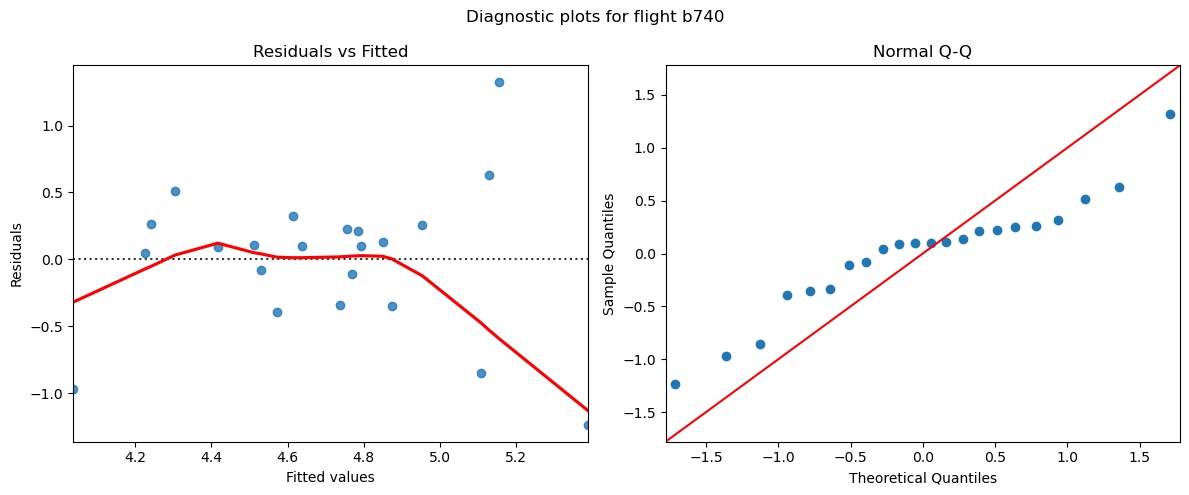

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1796: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1796: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1718: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


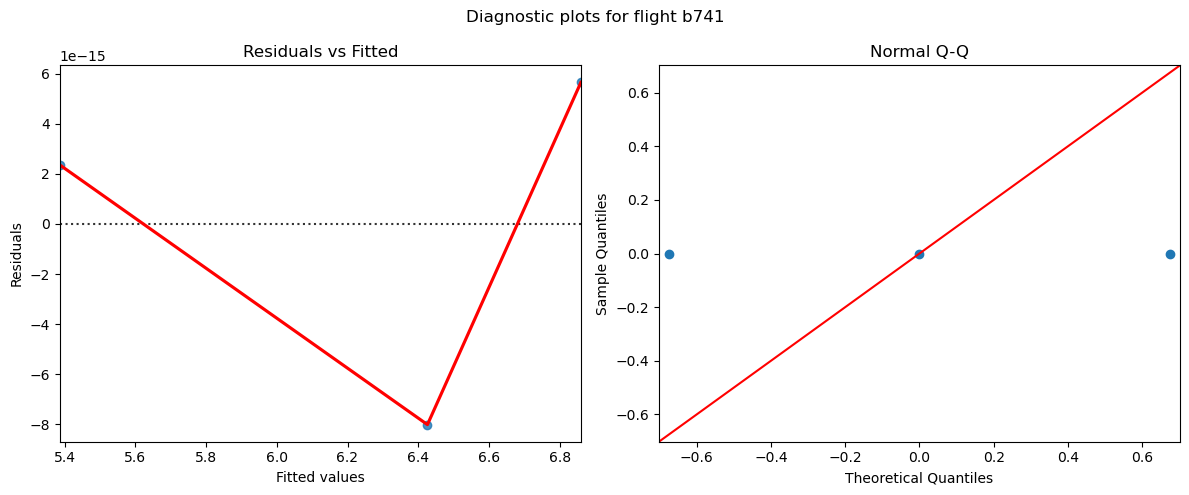

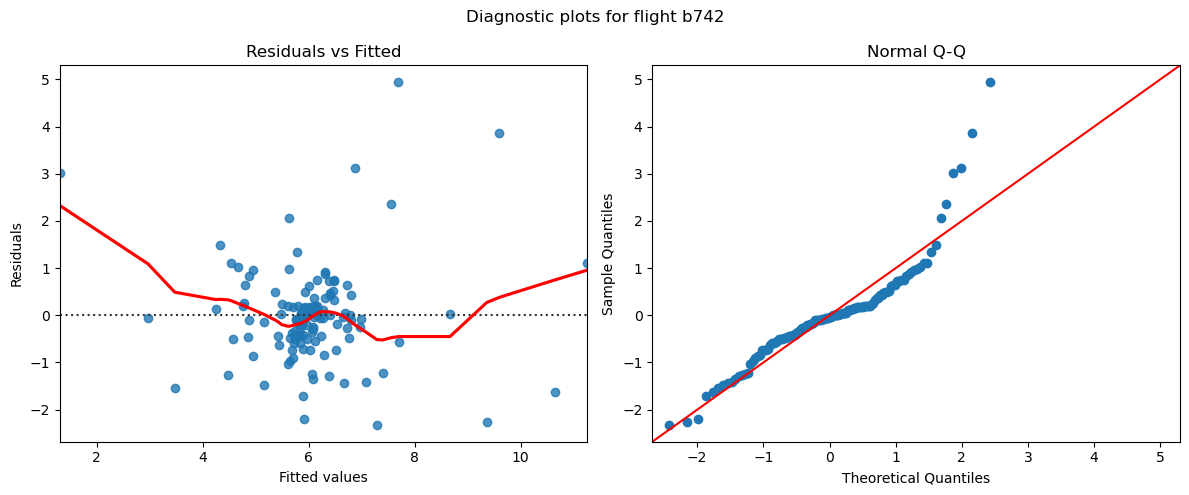

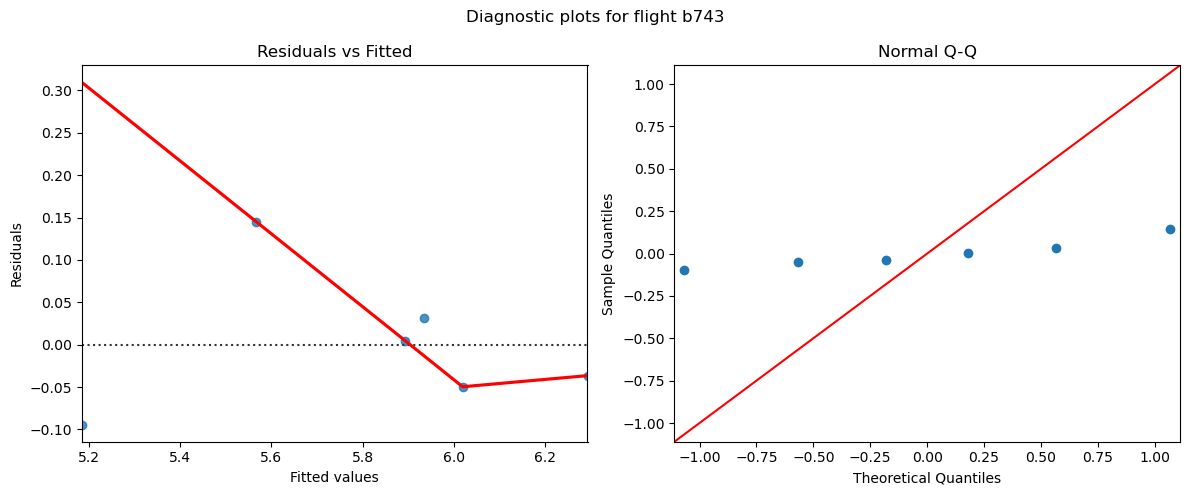

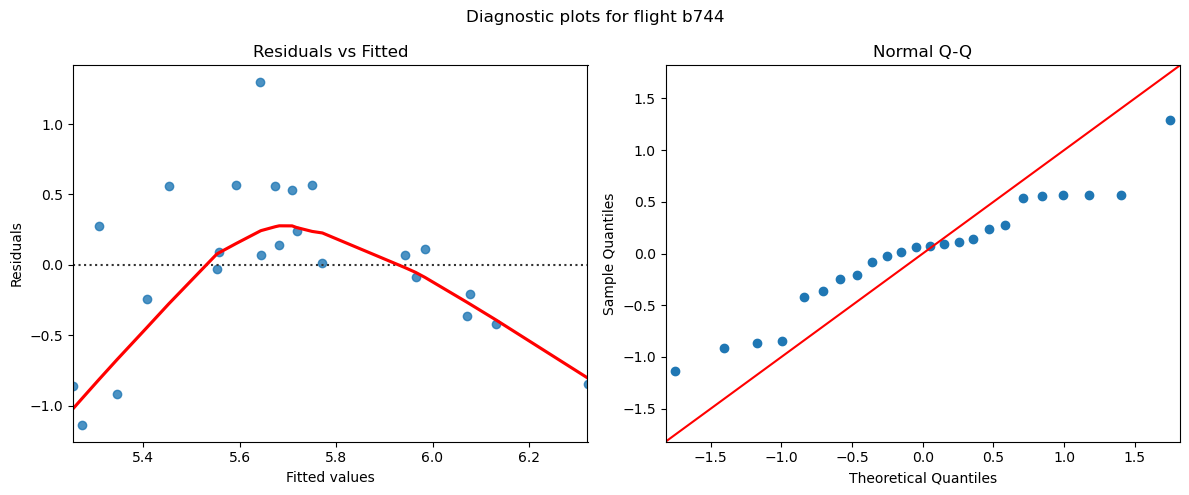

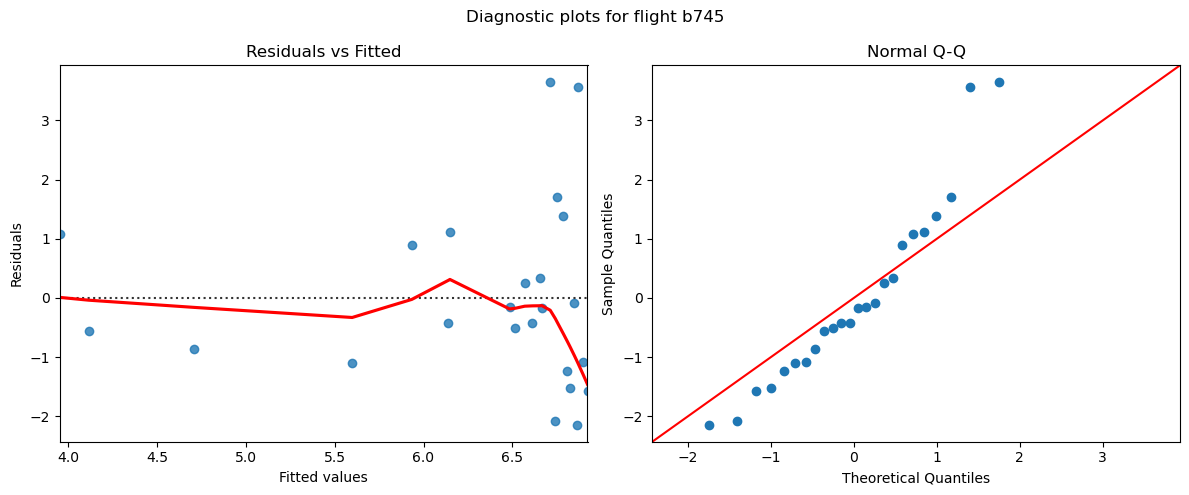

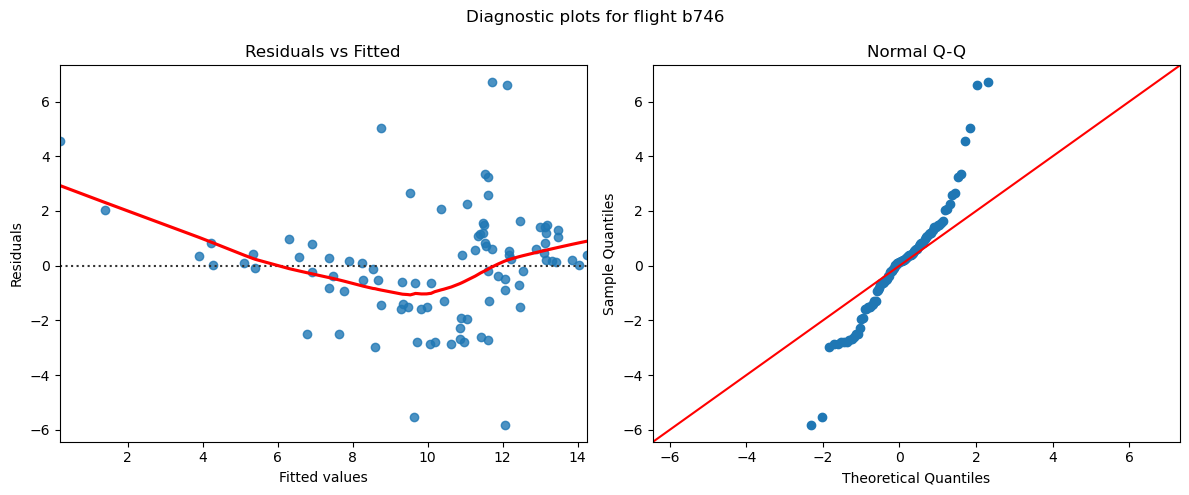

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1796: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1796: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1718: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


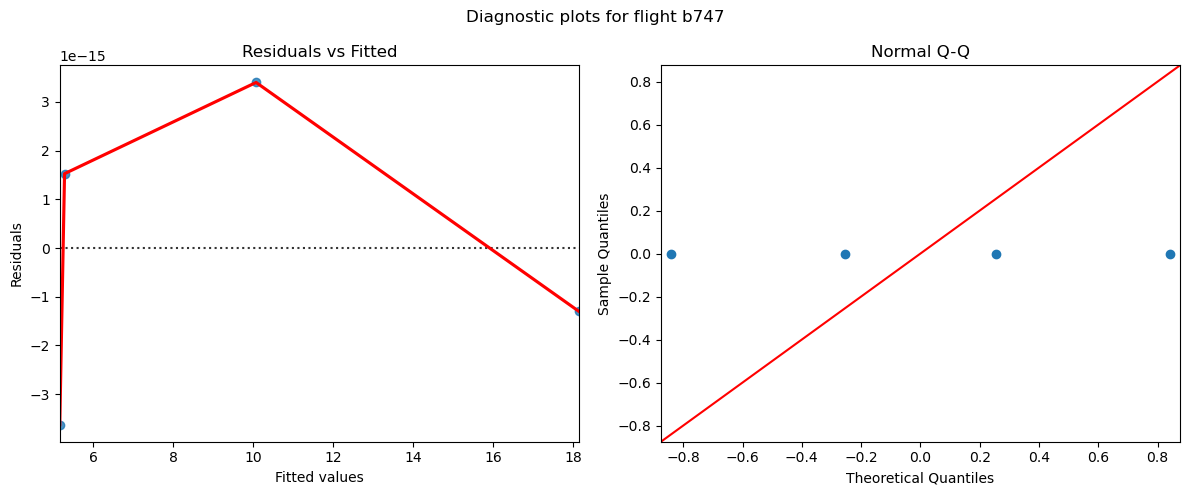

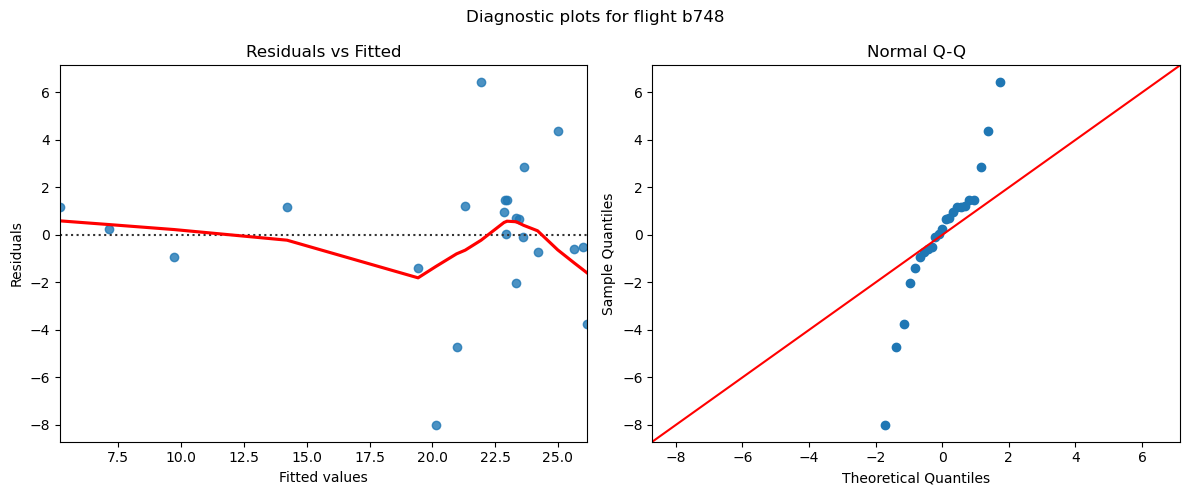

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1796: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1796: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1718: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


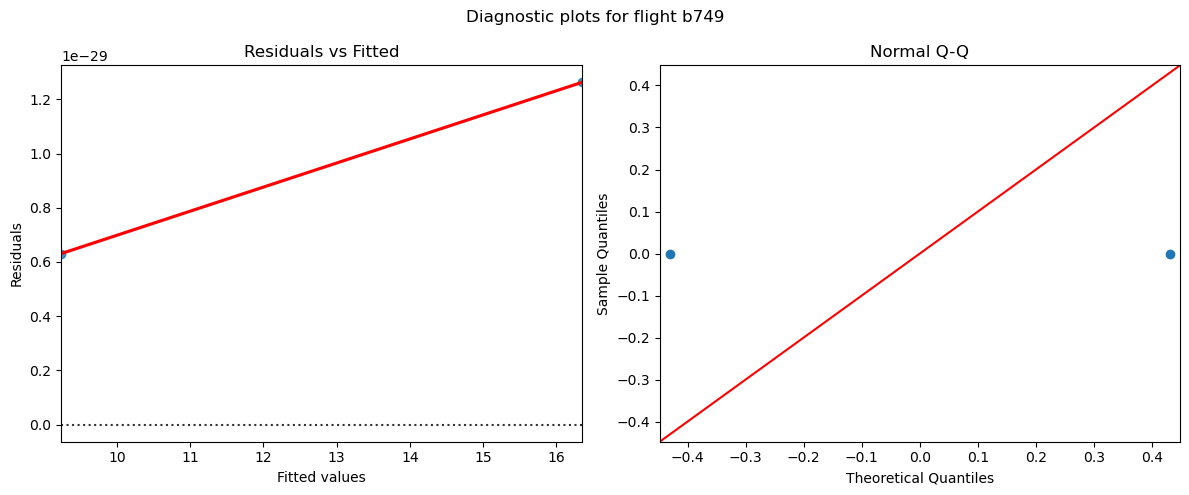

Error in flight b750: Cannot cast ufunc 'svd_m_s' input from dtype('O') to dtype('float64') with casting rule 'same_kind'
Flight Parameter  Coefficient  Std Err  p-value  R-squared  Adj R-squared  F-statistic F p-value
  b734     MODEL          NaN      NaN      NaN      0.753          0.746      101.708     0.000
  b734     const        5.600    0.323    0.000        NaN            NaN          NaN       NaN
  b734        BC        1.203    0.262    0.000        NaN            NaN          NaN       NaN
  b734       INO       -0.920    0.066    0.000        NaN            NaN          NaN       NaN
  b734       ORG        0.144    0.018    0.000        NaN            NaN          NaN       NaN
  b737     MODEL          NaN      NaN      NaN      0.170          0.129        4.102     0.010
  b737     const        5.412    0.465    0.000        NaN            NaN          NaN       NaN
  b737        BC        0.778    0.522    0.141        NaN            NaN          NaN       NaN
  b73

/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1783: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1796: RuntimeWarning: invalid value encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/srv/conda/envs/notebook/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1718: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


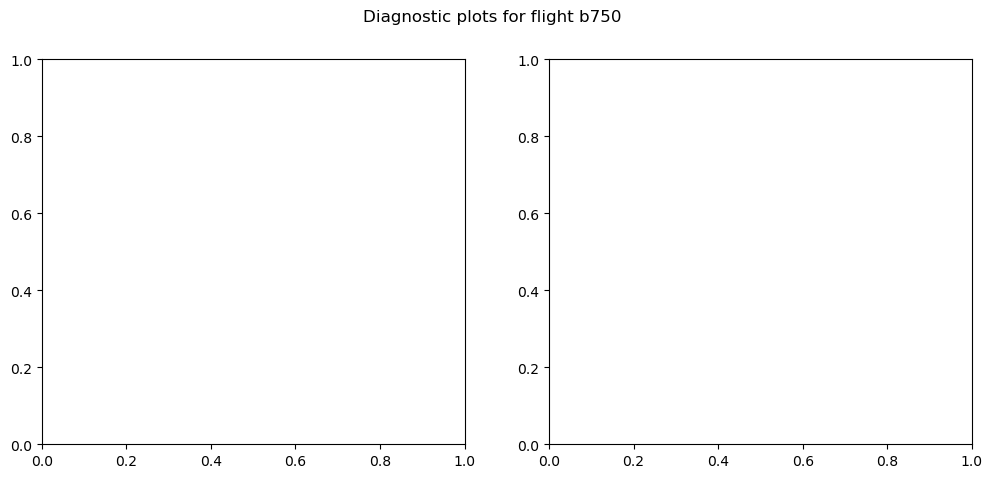

In [24]:
# Create an empty list to store the summary
regression_results = []

# Loop through each flight dict
for entry in results_sct:
    flight = entry['flight']
    
    try:
        # Build X and y
        X = pd.DataFrame({key: entry[key] for key in ['BC', 'INO', 'ORG']})
        y = pd.Series(entry['Mass scattering eff (growth correction)'])

        # Remove NaNs
        valid = X.notnull().all(axis=1) & ~np.isnan(y)
        X = X[valid]
        y = y[valid]

        # Add constant for intercept
        X_const = sm.add_constant(X)

        # Fit model
        model = sm.OLS(y, X_const).fit()

        # Add model-level metrics (only once per flight)
        model_metrics = {
            'Flight': flight,
            'Parameter': 'MODEL',
            'Coefficient': np.nan,
            'Std Err': np.nan,
            'p-value': np.nan,
            'R-squared': model.rsquared,
            'Adj R-squared': model.rsquared_adj,
            'F-statistic': model.fvalue,
            'F p-value': model.f_pvalue
        }
        regression_results.append(model_metrics)

        # Add coefficient-level stats
        for param, coef, std, pval in zip(model.params.index, model.params.values, model.bse.values, model.pvalues.values):
            regression_results.append({
                'Flight': flight,
                'Parameter': param,
                'Coefficient': coef,
                'Std Err': std,
                'p-value': pval,
                'R-squared': np.nan,
                'Adj R-squared': np.nan,
                'F-statistic': np.nan,
                'F p-value': np.nan
            })

        # === Diagnostic plots ===
        fig, axs = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f'Diagnostic plots for flight {flight}')

        # Residuals vs Fitted
        fitted_vals = model.fittedvalues
        residuals = model.resid
        sns.residplot(x=fitted_vals, y=residuals, lowess=True, ax=axs[0], line_kws={'color': 'red'})
        axs[0].set_xlabel("Fitted values")
        axs[0].set_ylabel("Residuals")
        axs[0].set_title("Residuals vs Fitted")

        # Q-Q plot
        sm.qqplot(residuals, line='45', ax=axs[1])
        axs[1].set_title("Normal Q-Q")

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error in flight {flight}: {e}")

# Convert to DataFrame
results_df = pd.DataFrame(regression_results)

# Display table
pd.set_option("display.max_columns", None)
print(results_df.to_string(index=False))

In [25]:
# Combine all flight data into a single dataframe
combined_data = []

for entry in results_sct:
    try:
        df = pd.DataFrame({
            'BC': entry['BC'],
            'INO': entry['INO'],
            'ORG': entry['ORG'],
            'ME': entry['Mass scattering eff (growth correction)'],
            'Flight': entry['flight']
        })
        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

# Concatenate all flights
df_all = pd.concat(combined_data, ignore_index=True)

# Drop rows with NaNs
df_all = df_all.dropna(subset=['BC', 'INO', 'ORG', 'ME'])

# Define predictors and target
X = df_all[['BC', 'INO', 'ORG']]
y = df_all['ME']

# Fit NNLS
coef, residual_norm = nnls(X.values, y.values)

# Predicted values and R²
y_pred = X @ coef
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r_squared = 1 - ss_res / ss_tot

# Display results
print("\n✅ Combined NNLS MLR across all flights:")
for param, c in zip(X.columns, coef):
    print(f"  {param}: {c:.4f}")
print(f"  R²: {r_squared:.4f}")
print(f"  Residual norm: {residual_norm:.4f}")
print(f"  N: {len(y)}")


✅ Combined NNLS MLR across all flights:
  BC: 2.9500
  INO: 0.8328
  ORG: 0.0000
  R²: -1.6788
  Residual norm: 159.4623
  N: 657


In [2]:
# Create the figure and axis
fig, ax1 = plt.subplots(figsize=(10, 5))

# Define data and corresponding style
species_data = {
    "BC":  (df_all['BC'].values, "black"),
    "INO": (df_all['INO'].values, "red"),
    "ORG": (df_all['ORG'].values, "green"),
}

# Plot all species in a loop
for label, (xdata, color) in species_data.items():
    ax1.plot(xdata, df_all['ME'].values,
             marker='.', linewidth=0, color=color, label=label)


ax1.set_xscale('log')
# Set labels and formatting
ax1.set_xlabel("Mass concentration (µg/m³)")
ax1.set_ylabel(r'Mass Scattering Coefficient (m²/g)')
#ax1.set_title(f"Flight {flight_number} - {flight_date}")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True)
ax1.legend(loc="best")

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

NameError: name 'df_all' is not defined

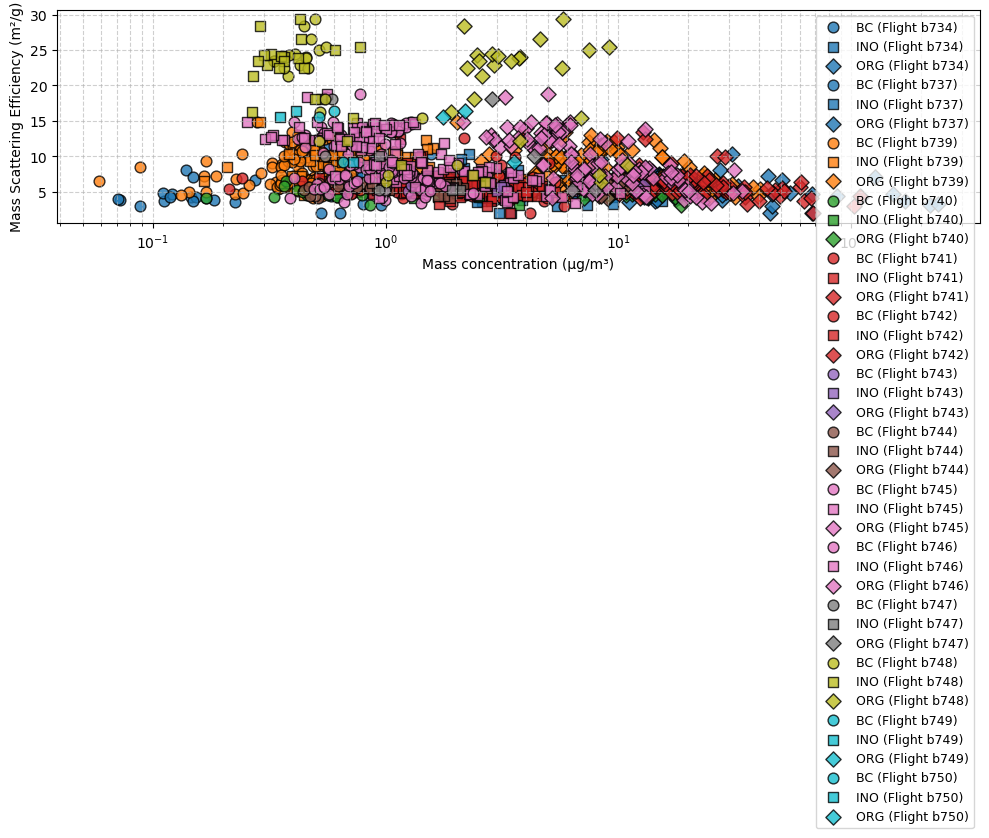

In [27]:
# Create the figure and axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Get unique flights and assign a color to each
unique_flights = df_all['Flight'].unique()
num_flights = len(unique_flights)
colors = plt.get_cmap('tab10', num_flights)  # You can change to 'tab20' for more flights

# Define unique markers for each species
species_markers = {
    "BC": "o",    # circle
    "INO": "s",   # square
    "ORG": "D",   # diamond
}

# Plot each point with a unique flight color and species marker
for i, flight in enumerate(unique_flights):
    flight_df = df_all[df_all["Flight"] == flight]
    flight_color = colors(i)
    
    for species, marker in species_markers.items():
        ax1.scatter(
            flight_df[species],
            flight_df["ME"],
            label=f"{species} (Flight {flight})",
            marker=marker,
            color=flight_color,
            edgecolor='k',
            alpha=0.8,
            s=60
        )

ax1.set_xscale('log')
ax1.set_xlabel("Mass concentration (µg/m³)")
ax1.set_ylabel("Mass Scattering Efficiency (m²/g)")
ax1.grid(True, which='both', linestyle='--', alpha=0.6)
ax1.legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()